# Linformer Fold-Factor LUT Sweep

Sweep the CMIR folded-design evaluator over the Linformer particle-count models and compare fold-factor 1 LUT(k) estimates against the Linformer rows from the reference table.

The notebook reports `area_proxy` as LUT count because `IR.sched_ir.scheduling.metrics.schedule_metrics` computes it as the sum of scheduled resource `cost["lut"]` values.

In [1]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "jax")
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "cmir-matplotlib"))

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "IR").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import keras
import hgq  # noqa: F401 - registers HGQ custom Keras layers

from IR import nn_ir
from IR.sched_ir import api


## Sweep Configuration

`fold_factors=None` means use every divisor of the particle count. Set it to a list, for example `[1, 2, 4]`, if you want a quicker run.

In [2]:
MODEL_SPECS = [
    {
        "model": "Linformer",
        "particles": 8,
        "path": REPO_ROOT / "official_models/linformers/lin8part.keras",
        "paper_acc_pct": 66.3,
        "paper_latency_ns": 110,
        "paper_fold1_lut_k": 230,
        "paper_ii_clk": 1,
        "paper_dsp": 0,
        "fold_factors": None,
    },
    {
        "model": "Linformer",
        "particles": 16,
        "path": REPO_ROOT / "official_models/linformers/lin16part.keras",
        "paper_acc_pct": 72.8,
        "paper_latency_ns": 103,
        "paper_fold1_lut_k": 246,
        "paper_ii_clk": 1,
        "paper_dsp": 0,
        "fold_factors": None,
    },
    {
        "model": "Linformer",
        "particles": 32,
        "path": REPO_ROOT / "official_models/linformers/lin32part.keras",
        "paper_acc_pct": 78.4,
        "paper_latency_ns": 140,
        "paper_fold1_lut_k": 267,
        "paper_ii_clk": 1,
        "paper_dsp": 0,
        "fold_factors": None,
    },
]

TARGET_FMAX_HZ = 300e6
OUTPUT_CSV = REPO_ROOT / "notebooks/linformer_fold_sweep_results.csv"


def divisor_fold_factors(particles: int) -> list[int]:
    return [factor for factor in range(1, particles + 1) if particles % factor == 0]


paper_baseline_df = pd.DataFrame(
    [
        {
            "model": spec["model"],
            "particles": spec["particles"],
            "paper_acc_pct": spec["paper_acc_pct"],
            "paper_latency_ns": spec["paper_latency_ns"],
            "paper_fold1_lut_k": spec["paper_fold1_lut_k"],
            "paper_ii_clk": spec["paper_ii_clk"],
            "paper_dsp": spec["paper_dsp"],
        }
        for spec in MODEL_SPECS
    ]
)
paper_baseline_df


,model,particles,paper_acc_pct,paper_latency_ns,paper_fold1_lut_k,paper_ii_clk,paper_dsp
0,Linformer,8,66.3,110,230,1,0
1,Linformer,16,72.8,103,246,1,0
2,Linformer,32,78.4,140,267,1,0


## Evaluation Helpers

In [3]:
def task_cost_rows(design, *, particles: int, fold_factor: int) -> list[dict]:
    rows = []
    for task_id, item in design.task_schedule.tasks.items():
        task = item.task
        resource = design.task_ir.resources.get(task.resource_id, {})
        cost = getattr(resource, "cost", {}) or {}
        rows.append(
            {
                "particles": particles,
                "fold_factor": fold_factor,
                "task_id": task_id,
                "task_name": getattr(task, "name", str(task_id)),
                "resource_id": task.resource_id,
                "start_cycle": item.start,
                "end_cycle": item.end,
                "duration_cycles": item.end - item.start,
                "ii": task.ii,
                "lut": int(cost.get("lut") or 0),
                "ff": int(cost.get("ff") or 0),
                "dsp": int(cost.get("dsp") or 0),
                "bram": int(cost.get("bram") or 0),
            }
        )
    return rows


def evaluate_fold(model, nn_graph, spec: dict, fold_factor: int) -> tuple[dict, list[dict]]:
    design = api.evaluate_folded_design(
        nn_graph,
        model=model,
        backend="da4ml",
        factor=fold_factor,
        target_fmax_hz=TARGET_FMAX_HZ,
    )
    lut = float(design.metrics.get("area_proxy", 0.0))
    row = {
        "model": spec["model"],
        "particles": spec["particles"],
        "model_path": str(spec["path"].relative_to(REPO_ROOT)),
        "fold_factor": fold_factor,
        "status": "ok",
        "lut": int(round(lut)),
        "lut_k": lut / 1000.0,
        "latency_cycles": design.metrics.get("latency_cycles"),
        "sample_ii_cycles": design.metrics.get("sample_ii_cycles"),
        "throughput_samples_per_sec": design.metrics.get("throughput_samples_per_sec"),
        "sync_point_count": design.metrics.get("sync_point_count"),
        "sync_violations": design.metrics.get("sync_violations"),
        "error": None,
    }
    return row, task_cost_rows(design, particles=spec["particles"], fold_factor=fold_factor)


def evaluate_model_sweep(spec: dict) -> tuple[list[dict], list[dict]]:
    fold_factors = spec["fold_factors"] or divisor_fold_factors(spec["particles"])
    print(f"Loading {spec['path'].relative_to(REPO_ROOT)}")
    model = keras.models.load_model(spec["path"])
    nn_graph = nn_ir.build_nn_ir(model)

    rows = []
    task_rows = []
    for fold_factor in fold_factors:
        print(f"  particles={spec['particles']} fold_factor={fold_factor}")
        try:
            row, per_task = evaluate_fold(model, nn_graph, spec, fold_factor)
            rows.append(row)
            task_rows.extend(per_task)
        except Exception as exc:
            rows.append(
                {
                    "model": spec["model"],
                    "particles": spec["particles"],
                    "model_path": str(spec["path"].relative_to(REPO_ROOT)),
                    "fold_factor": fold_factor,
                    "status": "failed",
                    "lut": None,
                    "lut_k": None,
                    "latency_cycles": None,
                    "sample_ii_cycles": None,
                    "throughput_samples_per_sec": None,
                    "sync_point_count": None,
                    "sync_violations": None,
                    "error": repr(exc),
                }
            )
            print(f"    failed: {exc!r}")
    return rows, task_rows


## Run Sweep

In [4]:
all_rows = []
all_task_rows = []

for spec in MODEL_SPECS:
    rows, task_rows = evaluate_model_sweep(spec)
    all_rows.extend(rows)
    all_task_rows.extend(task_rows)

results_df = pd.DataFrame(all_rows).sort_values(["particles", "fold_factor"]).reset_index(drop=True)
task_costs_df = pd.DataFrame(all_task_rows)

results_df


Loading official_models/linformers/lin8part.keras


/opt/homebrew/Caskroom/miniforge/base/envs/jedi-linear/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 204 variables whereas the saved optimizer has 208 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/sriharshavitta/Projects/CMIR/IR/nn_ir/builder.py:654: UserWarning: NN-IR vertex 'mha1_qk' has no input quantizer summary
  _validate(g)
/Users/sriharshavitta/Projects/CMIR/IR/nn_ir/builder.py:654: UserWarning: NN-IR vertex 'mha1_softmax' has no input quantizer summary
  _validate(g)
/Users/sriharshavitta/Projects/CMIR/IR/nn_ir/builder.py:654: UserWarning: NN-IR vertex 'mha1_av' has no input quantizer summary
  _validate(g)
/Users/sriharshavitta/Projects/CMIR/IR/nn_ir/builder.py:654: UserWarning: NN-IR vertex 'flatten_2' has no input quantizer summary
  _validate(g)
/Users/sriharshavitta/Projects/CMIR/IR/nn_ir/builder.py:654: UserWarning: NN-IR edge (8, 9) has no pr

  particles=8 fold_factor=1
  particles=8 fold_factor=2
  particles=8 fold_factor=4
  particles=8 fold_factor=8
Loading official_models/linformers/lin16part.keras
  particles=16 fold_factor=1
  particles=16 fold_factor=2
  particles=16 fold_factor=4
  particles=16 fold_factor=8
  particles=16 fold_factor=16
Loading official_models/linformers/lin32part.keras


/Users/sriharshavitta/Projects/CMIR/IR/nn_ir/builder.py:654: UserWarning: NN-IR vertex 'flatten_8' has no input quantizer summary
  _validate(g)


  particles=32 fold_factor=1
  particles=32 fold_factor=2
  particles=32 fold_factor=4
  particles=32 fold_factor=8
  particles=32 fold_factor=16
  particles=32 fold_factor=32


,model,particles,model_path,fold_factor,status,lut,lut_k,latency_cycles,sample_ii_cycles,throughput_samples_per_sec,sync_point_count,sync_violations,error
0,Linformer,8,official_models/linformers/lin8part.keras,1,ok,214490,214.490,99,1,300000000.0,5,0,None
1,Linformer,8,official_models/linformers/lin8part.keras,2,ok,142982,142.982,100,2,150000000.0,12,0,None
2,Linformer,8,official_models/linformers/lin8part.keras,4,ok,106835,106.835,105,4,75000000.0,18,0,None
3,Linformer,8,official_models/linformers/lin8part.keras,8,ok,88583,88.583,110,8,37500000.0,30,0,None
4,Linformer,16,official_models/linformers/lin16part.keras,1,ok,221822,221.822,96,1,300000000.0,5,0,None
5,Linformer,16,official_models/linformers/lin16part.keras,2,ok,154417,154.417,96,2,150000000.0,12,0,None
6,Linformer,16,official_models/linformers/lin16part.keras,4,ok,119888,119.888,100,4,75000000.0,18,0,None
7,Linformer,16,official_models/linformers/lin16part.keras,8,ok,102324,102.324,107,8,37500000.0,30,0,None
8,Linformer,16,official_models/linformers/lin16part.keras,16,ok,93357,93.357,124,16,18750000.0,54,0,None
9,Linformer,32,official_models/linformers/lin32part.keras,1,ok,244471,244.471,83,1,300000000.0,5,0,None


## LUT(k) Pivot by Fold Factor

In [5]:
lut_pivot_df = (
    results_df[results_df["status"].eq("ok")]
    .pivot(index="particles", columns="fold_factor", values="lut_k")
    .sort_index()
)
lut_pivot_df.columns = [f"fold_{col}_lut_k" for col in lut_pivot_df.columns]
lut_pivot_df


,fold_1_lut_k,fold_2_lut_k,fold_4_lut_k,fold_8_lut_k,fold_16_lut_k,fold_32_lut_k
particles,,,,,,
8,214.490,142.982,106.835,88.583,NaN,NaN
16,221.822,154.417,119.888,102.324,93.357,NaN
32,244.471,180.093,146.978,130.370,122.221,118.461


## LUT(k) vs Fold Factor

Saved plot to notebooks/linformer_lut_vs_fold_factor.png


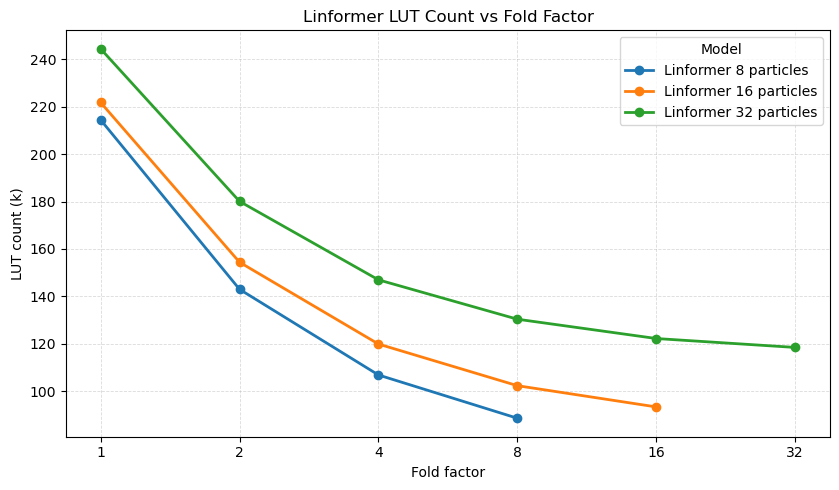

In [9]:
import matplotlib.pyplot as plt

plot_df = results_df[results_df["status"].eq("ok")].copy()

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for particles, group in plot_df.groupby("particles"):
    group = group.sort_values("fold_factor")
    ax.plot(
        group["fold_factor"],
        group["lut_k"],
        marker="o",
        linewidth=2,
        label=f"Linformer {particles} particles",
    )

ax.set_title("Linformer LUT Count vs Fold Factor")
ax.set_xlabel("Fold factor")
ax.set_ylabel("LUT count (k)")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(plot_df["fold_factor"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.45)
ax.legend(title="Model")
fig.tight_layout()

lut_plot_path = REPO_ROOT / "notebooks/linformer_lut_vs_fold_factor.png"
fig.savefig(lut_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved plot to {lut_plot_path.relative_to(REPO_ROOT)}")
plt.show()


## Fold-Factor 1 Comparison Against Reference Table

In [11]:
fold1_compare_df = (
    results_df[results_df["fold_factor"].eq(1)]
    .merge(paper_baseline_df, on=["model", "particles"], how="left")
    .assign(
        delta_lut_k=lambda df: df["lut_k"] - df["paper_fold1_lut_k"],
        delta_lut_pct=lambda df: 100.0 * (df["lut_k"] - df["paper_fold1_lut_k"]) / df["paper_fold1_lut_k"],
    )
    [
        [
            "model",
            "particles",
            "status",
            "lut_k",
            "paper_fold1_lut_k",
            "delta_lut_k",
            "delta_lut_pct",
            "latency_cycles",
            "sample_ii_cycles",
            "paper_latency_ns",
            "paper_ii_clk",
            "error",
        ]
    ]
)
# rename latency_cycles to latency_cycles_proxy
fold1_compare_df = fold1_compare_df.rename(columns={"latency_cycles": "latency_cycles_proxy"})

fold1_compare_df


,model,particles,status,lut_k,paper_fold1_lut_k,delta_lut_k,delta_lut_pct,latency_cycles_proxy,sample_ii_cycles,paper_latency_ns,paper_ii_clk,error
0,Linformer,8,ok,214.490,230,-15.510,-6.743478,99,1,110,1,None
1,Linformer,16,ok,221.822,246,-24.178,-9.828455,96,1,103,1,None
2,Linformer,32,ok,244.471,267,-22.529,-8.437828,83,1,140,1,None


## Optional Per-Task LUT Breakdown

Use this to inspect which scheduled resources dominate a particular `(particles, fold_factor)` row.

In [7]:
if not task_costs_df.empty:
    task_lut_summary_df = (
        task_costs_df.groupby(["particles", "fold_factor", "task_name"], as_index=False)
        .agg(lut=("lut", "sum"), max_ii=("ii", "max"), instances=("task_id", "count"))
        .sort_values(["particles", "fold_factor", "lut"], ascending=[True, True, False])
    )
else:
    task_lut_summary_df = pd.DataFrame()

task_lut_summary_df.head(30)


,particles,fold_factor,task_name,lut,max_ii,instances
4,8,1,node:12,32172,1,1
7,8,1,node:15,26270,1,1
5,8,1,node:13,25887,1,1
1,8,1,node:1,24726,1,1
8,8,1,node:16,24471,1,1
11,8,1,node:19,16224,1,1
2,8,1,node:10,14856,1,1
0,8,1,node:0,9003,1,1
18,8,1,node:7,5872,1,1
17,8,1,node:6,5704,1,1


## Save Results

In [8]:
results_df.to_csv(OUTPUT_CSV, index=False)
task_costs_path = OUTPUT_CSV.with_name("linformer_fold_sweep_task_costs.csv")
task_costs_df.to_csv(task_costs_path, index=False)

print(f"Saved sweep results to {OUTPUT_CSV.relative_to(REPO_ROOT)}")
print(f"Saved task costs to {task_costs_path.relative_to(REPO_ROOT)}")


Saved sweep results to notebooks/linformer_fold_sweep_results.csv
Saved task costs to notebooks/linformer_fold_sweep_task_costs.csv
